Author: Dhrubajyoti Ghosh
Assignment: Supervised Machine Learning
Version: 1.0
Date: 25 May 2026
--------------------------------------------

In [3]:
#importing libraries
import pandas as pd
import time
import math
import numpy as np

import pickle

import plotly as py
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import scipy.stats as stat
from scipy.stats import norm
from scipy.stats import f_oneway
from scipy.stats import boxcox

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV, RandomizedSearchCV



In [124]:
#importing libraries for ML Regressor Models


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, BaggingRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from xgboost import XGBRegressor

-------------------------------------------------------------------------------------------------------------
**Question b):**
-------------------------------------------------------------------------------------------------------------
Use the Life Expectancy Prediction dataset from below Kaggle link and create an end to end project on Jupyter/Colab.

https://www.kaggle.com/datasets/vikramamin/life-expectancy-who/data

i.	Download the dataset from above link and load it into your Python environment.

ii.	Perform the EDA and do the visualizations.

iii.	Check the distributions/skewness in the variables and do the transformations if required.

iv.	Check/Treat the outliers and do the feature scaling if required.

v.	Create a ML model to predict the life expectancy based on the specifications given.

vi.	Check for overfitting and treat them accordingly.

vii.	Use all the Supervised ML algorithms (DT, RF, SVM, XGBoost etc.) and compare the performances to get the best model.

-------------------------------------------------------------------------------------------------------------------------------------------------


In [4]:
#Question b (i): Download the dataset from above link and load it into your Python environment.

df = pd.read_csv('Life Expectancy Data.csv')
df

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.000000,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.000000,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.000000,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.000000,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


In [5]:
df.columns

Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

In [6]:
#Question b (ii): Perform the EDA and do the visualizations.
#Renaming the columns

df = df.rename(columns={
    "Life expectancy ": "life_expectancy",
    "Adult Mortality": "adult_mortality",
    "infant deaths": "infant_deaths",
    "percentage expenditure": "percentage_expenditure",
    "Hepatitis B": "hepatitis_b",
    "Measles ": "measles",
    " BMI ": "bmi",
    "under-five deaths ": "under_five_deaths",
    "Total expenditure": "total_expenditure",
    "Diphtheria ": "diphtheria",
    " HIV/AIDS": "hiv_aids",
    " thinness  1-19 years": "thinness_1_19yrs",
    " thinness 5-9 years": "thinness_5_9yrs",
    "Income composition of resources": "income_composition"
})

df = df.rename(columns=str.lower)

df.columns

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19yrs',
       'thinness_5_9yrs', 'income_composition', 'schooling'],
      dtype='object')

In [46]:
#Question b (ii): Perform the EDA and do the visualizations.
#Generating summary about the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 2938 non-null   object 
 1   year                    2938 non-null   int64  
 2   status                  2938 non-null   object 
 3   life_expectancy         2928 non-null   float64
 4   adult_mortality         2928 non-null   float64
 5   infant_deaths           2938 non-null   int64  
 6   alcohol                 2744 non-null   float64
 7   percentage_expenditure  2938 non-null   float64
 8   hepatitis_b             2385 non-null   float64
 9   measles                 2938 non-null   int64  
 10  bmi                     2904 non-null   float64
 11  under_five_deaths       2938 non-null   int64  
 12  polio                   2919 non-null   float64
 13  total_expenditure       2712 non-null   float64
 14  diphtheria              2919 non-null   

In [47]:
#Question b (ii): Perform the EDA and do the visualizations.
#checking for null values
df.isnull().sum().to_frame(name="null_count").reset_index().rename(columns={"index": "column_name"})

,column_name,null_count
0,country,0
1,year,0
2,status,0
3,life_expectancy,10
4,adult_mortality,10
5,infant_deaths,0
6,alcohol,194
7,percentage_expenditure,0
8,hepatitis_b,553
9,measles,0


In [48]:
#Question b (ii): Perform the EDA and do the visualizations.
#treating null values
#dropping the rows where population and life_expectancy is null which also removes the rows where adult_mortality is null
#Replacing bmi, total_expenditure, gdp, income_composition and schooling with mean values
#Replacing alcohol, hepatitis_b, polio, diphtheria, thinness_1_19yrs and thinness_5_9yrs with 0

#dropping the rows where population and life_expectancy is null which also removes the rows where adult_mortality is null
df = df.dropna(subset=['population', 'life_expectancy'])
len(df)

2284

In [49]:
#Question b (ii): Perform the EDA and do the visualizations.
#treating null values
#Replacing bmi, total_expenditure, gdp, income_composition and schooling with mean values

cols_mean_replace = ['bmi', 'total_expenditure', 'gdp', 'income_composition', 'schooling']
df[cols_mean_replace] = df[cols_mean_replace].fillna(df[cols_mean_replace].mean())

In [50]:
#Question b (ii): Perform the EDA and do the visualizations.
#treating null values
#Replacing alcohol, hepatitis_b, polio, diphtheria, thinness_1_19yrs and thinness_5_9yrs with 0

cols_zero_replace = ['alcohol', 'hepatitis_b', 'polio', 'diphtheria', 'thinness_1_19yrs', 'thinness_5_9yrs']
df[cols_zero_replace] = df[cols_zero_replace].fillna(0)

In [51]:
#Question b (ii): Perform the EDA and do the visualizations.
#treating null values
#cross checking the results
df.isnull().sum().to_frame(name="null_count").reset_index().rename(columns={"index": "column_name"})

,column_name,null_count
0,country,0
1,year,0
2,status,0
3,life_expectancy,0
4,adult_mortality,0
5,infant_deaths,0
6,alcohol,0
7,percentage_expenditure,0
8,hepatitis_b,0
9,measles,0


In [52]:
#Question b (ii): Perform the EDA and do the visualizations.
#treating null values
#checking final row count
len(df)

2284

In [53]:
#Question b (ii): Perform the EDA and do the visualizations.
#checking for duplicate rows
int(df.duplicated().sum()) #finding number of duplicate rows and converting it into integer.

0

In [54]:
#Question b (ii): Perform the EDA and do the visualizations.
#Checking the dimensions of the dataframe
df.shape

(2284, 22)

In [55]:
#Question b (ii): Perform the EDA and do the visualizations.
#Checking information about dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2284 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   country                 2284 non-null   object 
 1   year                    2284 non-null   int64  
 2   status                  2284 non-null   object 
 3   life_expectancy         2284 non-null   float64
 4   adult_mortality         2284 non-null   float64
 5   infant_deaths           2284 non-null   int64  
 6   alcohol                 2284 non-null   float64
 7   percentage_expenditure  2284 non-null   float64
 8   hepatitis_b             2284 non-null   float64
 9   measles                 2284 non-null   int64  
 10  bmi                     2284 non-null   float64
 11  under_five_deaths       2284 non-null   int64  
 12  polio                   2284 non-null   float64
 13  total_expenditure       2284 non-null   float64
 14  diphtheria              2284 non-null   float

In [56]:
#Question b (ii): Perform the EDA and do the visualizations.
#Fetching the column names
col_name = df.columns
col_name

Index(['country', 'year', 'status', 'life_expectancy', 'adult_mortality',
       'infant_deaths', 'alcohol', 'percentage_expenditure', 'hepatitis_b',
       'measles', 'bmi', 'under_five_deaths', 'polio', 'total_expenditure',
       'diphtheria', 'hiv_aids', 'gdp', 'population', 'thinness_1_19yrs',
       'thinness_5_9yrs', 'income_composition', 'schooling'],
      dtype='object')

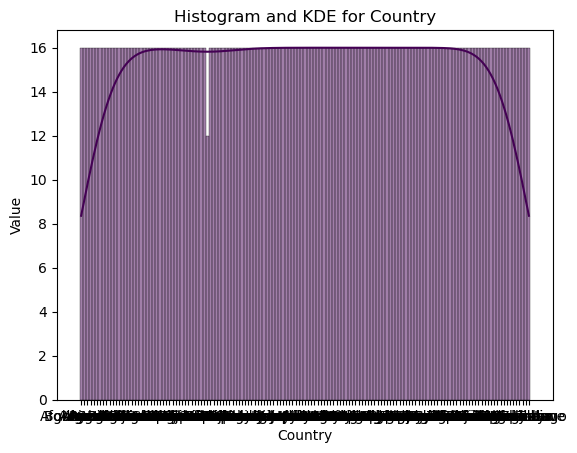

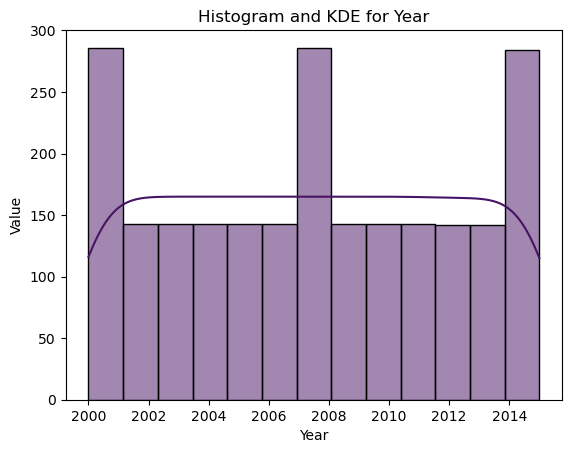

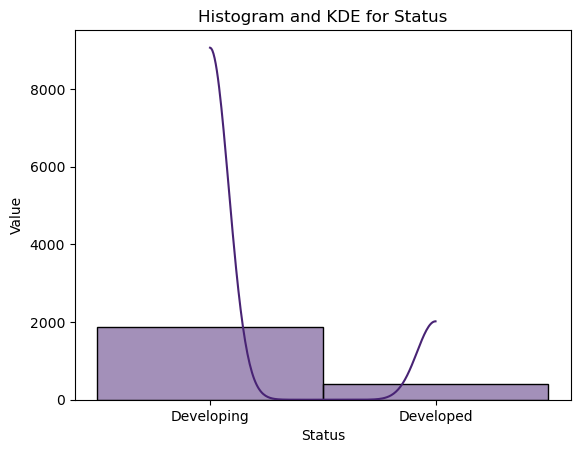

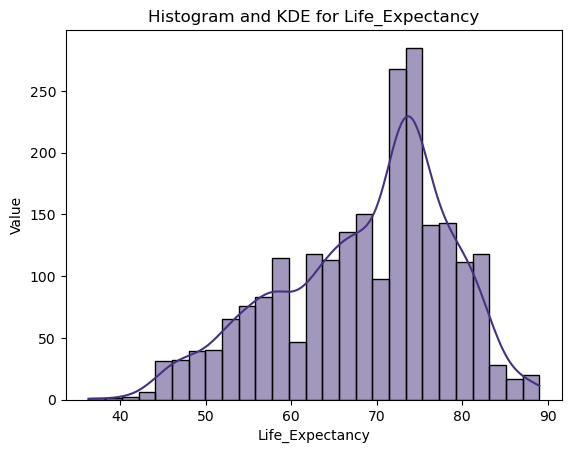

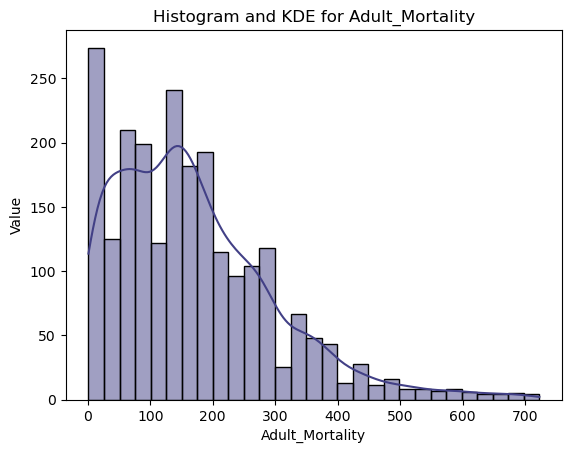

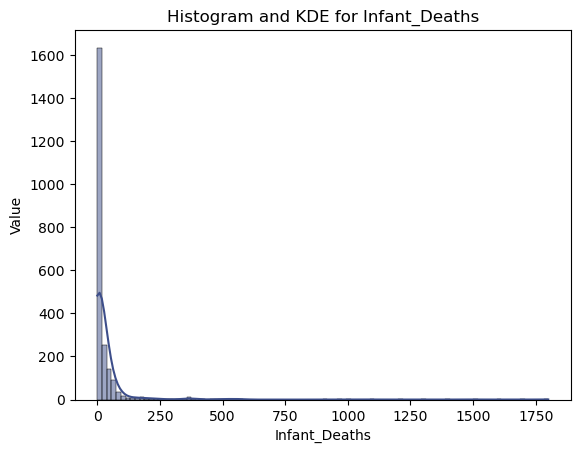

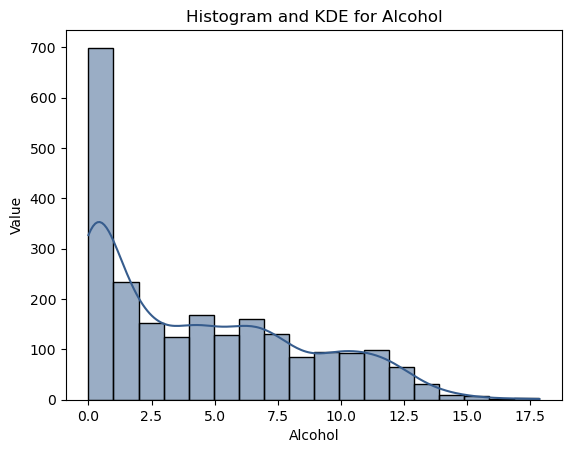

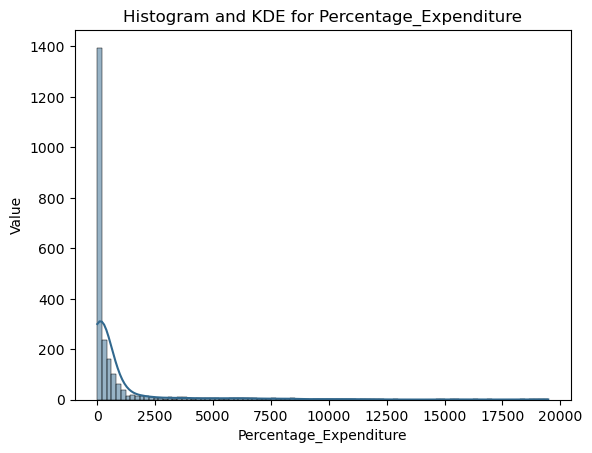

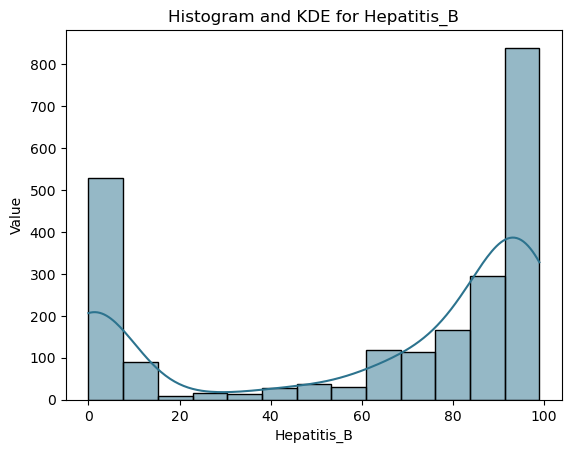

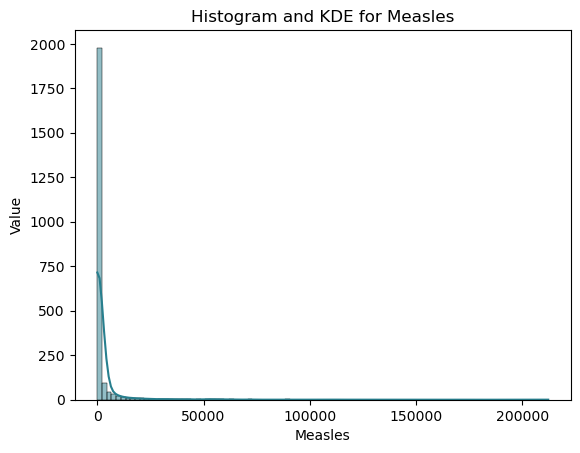

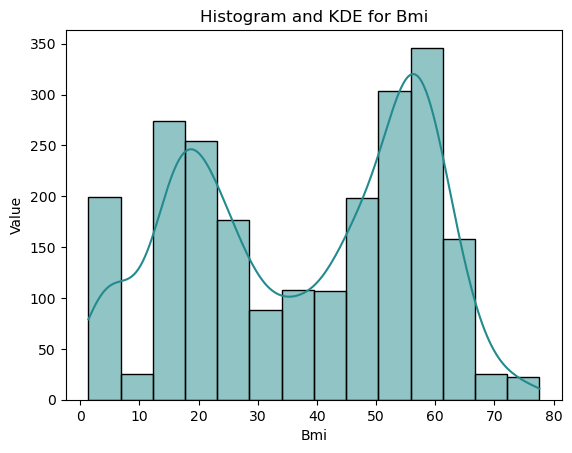

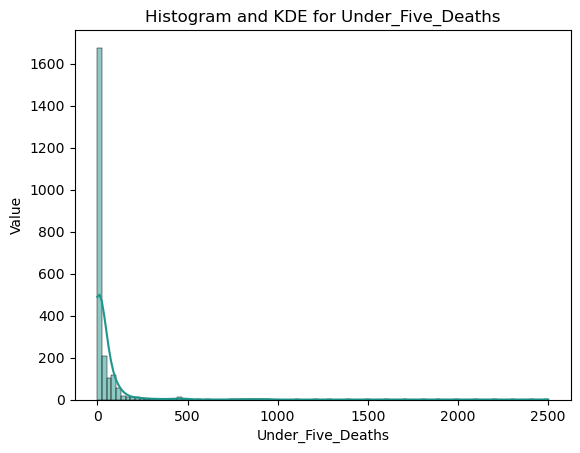

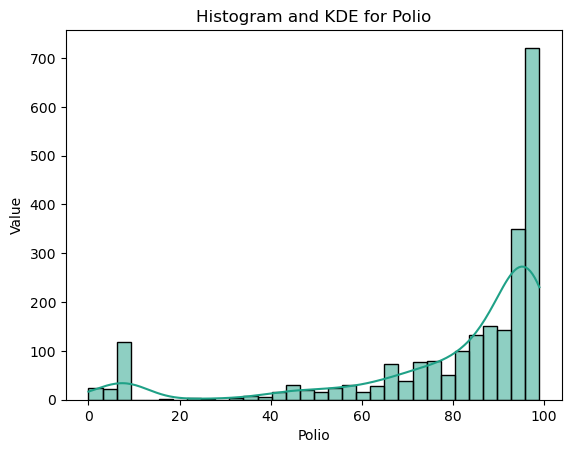

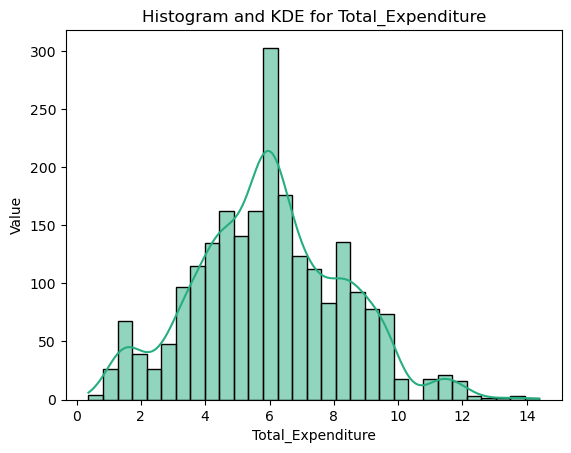

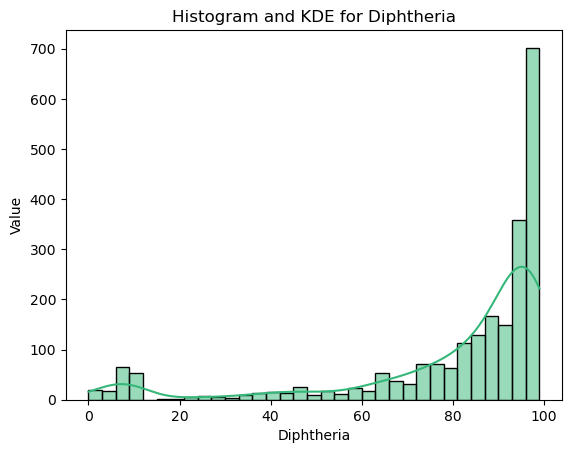

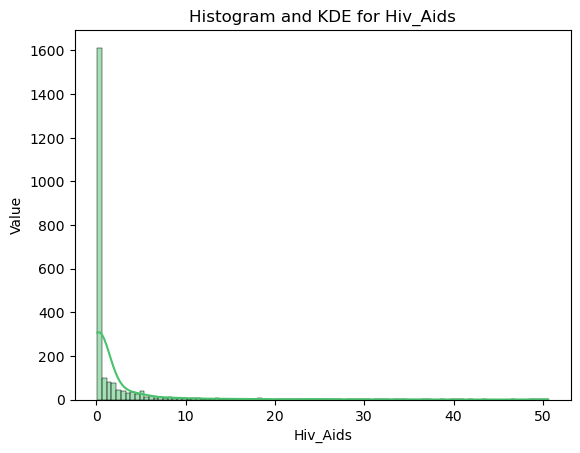

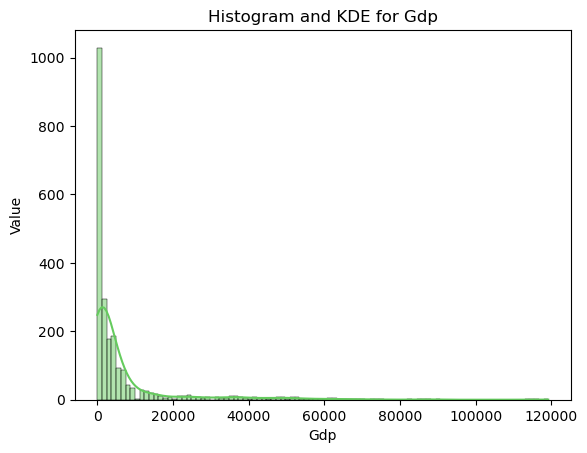

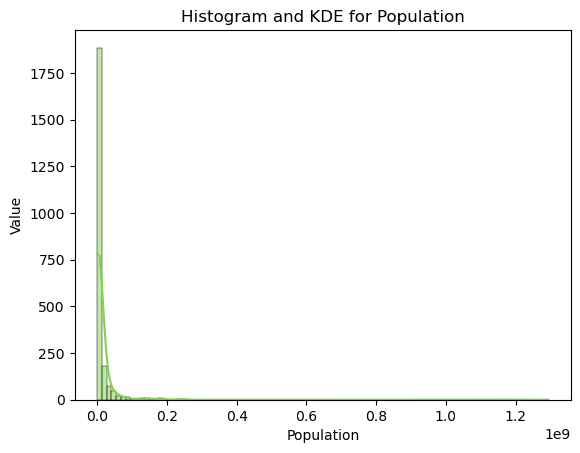

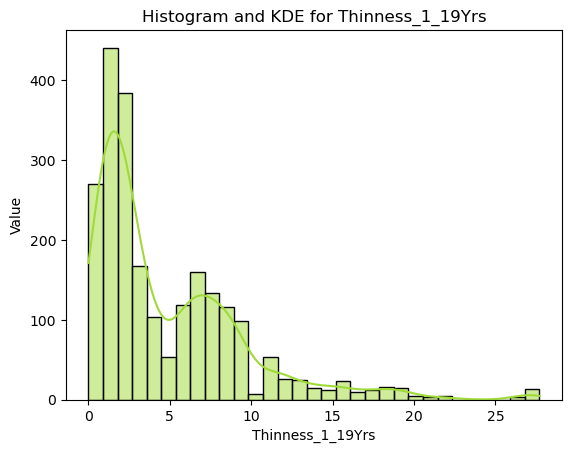

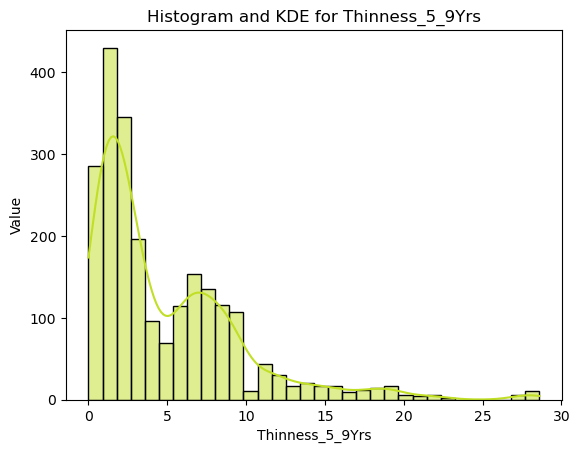

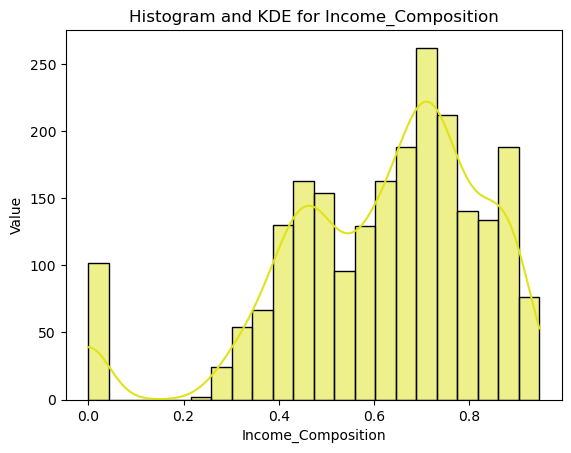

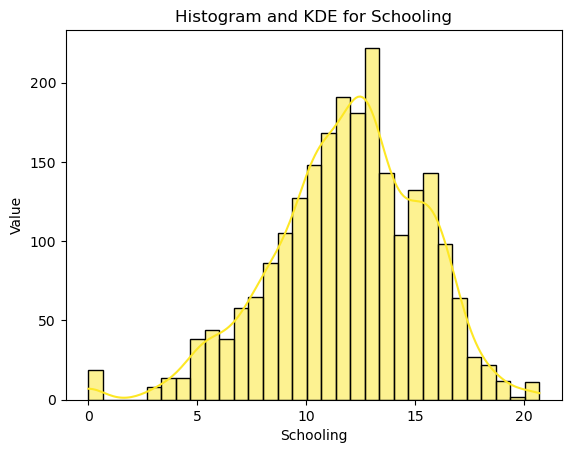

In [57]:
#Question b (ii): Perform the EDA and do the visualizations.
#Performing Data Visualization to check skewness

colors = plt.cm.viridis(np.linspace(0, 1, len(df.columns)))
for colm, color in zip(df.columns, colors):
    sns.histplot(df[colm], kde=True, color=color)
    col_name = str.title(colm)
    plt.title(f'Histogram and KDE for {col_name}')
    plt.xlabel(col_name)
    plt.ylabel('Value')
    plt.show()

In [58]:
#Question b: Perfroming train test split
#Independent Variables
x = df.drop("life_expectancy", axis = 1)
#Dependent Variable
y = df["life_expectancy"]

In [59]:
#Question b: Perfroming train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 3)

In [60]:
#Question b: Perfroming Ordinal Encoding on categorical data
#Using OrdinalEncoder for multiple columns. OneHotEncoder is not selected for creation of multiple columns.
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_train[['country', 'status']] = oe.fit_transform(x_train[['country', 'status']])
x_test[['country', 'status']] = oe.transform(x_test[['country', 'status']])

In [61]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#identifying skewed columns

#Creating a function to check positive and negative skewness
def check_skew_dirn(val):
    if val > 0:
        return "Positive/Right"
    elif val < 0:
        return "Negative/Left"
    else:
        return "No Skew"

In [62]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#identifying skewed columns

#Creating a function to categorize columns as per skewness

def categorize_skew(val):
    abs_skew = abs(val)
    
    if abs_skew < 0.5:
        lvl = "Lightly skewed"
    elif abs_skew < 1:
        lvl = "Moderately skewed"
    else:
        lvl = "Highly skewed"
    
    return lvl

In [63]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Checking Skewness
df_skewness = x_train.skew().to_frame(name="skewness").reset_index().rename(columns={"index": "column_name"})
df_skewness

,column_name,skewness
0,country,0.012415
1,year,0.005791
2,status,-1.628413
3,adult_mortality,1.202011
4,infant_deaths,9.127090
5,alcohol,0.661227
6,percentage_expenditure,4.252592
7,hepatitis_b,-0.750601
8,measles,9.430568
9,bmi,-0.180952


In [64]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Checking skewness of the columns

df_skewness_cpy = df_skewness.copy()
df_skewness_cpy["skew_category"] = df_skewness_cpy["skewness"].apply(categorize_skew)
df_skewness_cpy

,column_name,skewness,skew_category
0,country,0.012415,Lightly skewed
1,year,0.005791,Lightly skewed
2,status,-1.628413,Highly skewed
3,adult_mortality,1.202011,Highly skewed
4,infant_deaths,9.127090,Highly skewed
5,alcohol,0.661227,Moderately skewed
6,percentage_expenditure,4.252592,Highly skewed
7,hepatitis_b,-0.750601,Moderately skewed
8,measles,9.430568,Highly skewed
9,bmi,-0.180952,Lightly skewed


In [65]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Checking skewness direction of the columns
df_skewness_cpy["skew_direction"] = df_skewness_cpy["skewness"].apply(check_skew_dirn)
df_skewness_cpy

,column_name,skewness,skew_category,skew_direction
0,country,0.012415,Lightly skewed,Positive/Right
1,year,0.005791,Lightly skewed,Positive/Right
2,status,-1.628413,Highly skewed,Negative/Left
3,adult_mortality,1.202011,Highly skewed,Positive/Right
4,infant_deaths,9.127090,Highly skewed,Positive/Right
5,alcohol,0.661227,Moderately skewed,Positive/Right
6,percentage_expenditure,4.252592,Highly skewed,Positive/Right
7,hepatitis_b,-0.750601,Moderately skewed,Negative/Left
8,measles,9.430568,Highly skewed,Positive/Right
9,bmi,-0.180952,Lightly skewed,Negative/Left


In [66]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Identifying highly and moderately skewed columns and converting it into a list
skewed_cols = df_skewness_cpy[
    df_skewness_cpy["skew_category"].isin([
        "Highly skewed",
        "Moderately skewed"
    ])
]["column_name"].tolist()
skewed_cols

['status',
 'adult_mortality',
 'infant_deaths',
 'alcohol',
 'percentage_expenditure',
 'hepatitis_b',
 'measles',
 'under_five_deaths',
 'polio',
 'diphtheria',
 'hiv_aids',
 'gdp',
 'population',
 'thinness_1_19yrs',
 'thinness_5_9yrs',
 'income_composition']

#Question b (iv): Check/Treat the outliers and do the feature scaling if required.
#Function to identify & clip outliers
#Here, values below lower will be replaced with lower limit will be replaced with Lower limit value 
#and values above the upper limit will be replaced with upper limit value and values in between shall remain unchanged

#Below is IQR method

def manage_outliers(col_df, col_name):
    Q1 = col_df[col_name].quantile(0.25)
    Q3 = col_df[col_name].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.*IQR
    col_df[col_name] = col_df[col_name].clip(lower,upper)
    return col_df

In [67]:
#Question b (iv): Check/Treat the outliers and do the feature scaling if required.
#Function to identify & clip outliers
#Here, values below lower will be replaced with lower limit will be replaced with Lower limit value 
#and values above the upper limit will be replaced with upper limit value and values in between shall remain unchanged

#Below is Capping & Flooring method

def manage_outliers(col_df, col_name):
    lower = col_df[col_name].quantile(0.01)
    upper = col_df[col_name].quantile(0.99)
    col_df[col_name] = col_df[col_name].clip(lower,upper)
    return col_df

In [68]:
#Question b (iv): Check/Treat the outliers and do the feature scaling if required.
#Treating Outliers for Training Dataset
#Note: Outliers should be handled in training dataset only
for col in x_train.columns:
    x_train = manage_outliers(x_train, col)

In [69]:
#Question b (iv): Check/Treat the outliers and do the feature scaling if required.
#new value of training dataset after outlier treatment
x_train.head()

,country,year,status,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19yrs,thinness_5_9yrs,income_composition,schooling
1560,77.0,2009,1.0,254.0,33.0,0.91,71.166012,77.0,0.0,17.6,...,76.0,4.70,77.0,0.5,415.689323,2569121.0,7.7,7.6,0.500,9.7
4,1.0,2011,1.0,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
1775,89.0,2004,1.0,429.0,82.0,1.54,46.581956,76.0,9396.0,18.1,...,69.0,5.91,83.0,15.9,336.331815,231275.0,3.9,3.8,0.332,7.0
1308,65.0,2005,1.0,161.0,1.0,3.59,16.975116,99.0,0.0,46.3,...,99.0,4.70,99.0,1.9,482.247620,2744673.0,1.9,1.7,0.706,12.4
2122,106.0,2012,0.0,138.0,2.0,9.58,1078.358105,96.0,7450.0,58.4,...,92.0,5.48,91.0,0.1,8558.397660,25835.0,2.8,3.0,0.797,15.3


In [70]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Treating skewness using PowerTransformer - Training Dataset
pt = PowerTransformer(method="yeo-johnson")
x_train[skewed_cols] = pt.fit_transform(x_train[skewed_cols]) #for power transform
x_train

,country,year,status,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19yrs,thinness_5_9yrs,income_composition,schooling
1560,77.0,2009,0.475604,0.795316,1.084394,-0.790155,-0.139404,0.433991,-1.140341,17.600000,...,-0.553069,4.700000,-0.560355,0.309040,-0.729717,0.264966,0.944695,0.914484,-0.750215,9.700
4,1.0,2011,0.475604,0.913732,1.389904,-1.394172,-1.031902,0.250665,1.330961,17.200000,...,-0.957067,7.870000,-1.030948,-0.746804,-1.732010,0.326991,1.881721,1.884346,-0.941245,9.500
1775,89.0,2004,0.475604,1.652150,1.442377,-0.499060,-0.312947,0.413940,1.536749,18.100000,...,-0.910115,5.910000,-0.192757,1.854379,-0.843995,-0.654430,0.209147,0.166742,-1.379870,7.000
1308,65.0,2005,0.475604,0.185047,-0.645161,0.149849,-0.711896,0.858008,-1.140341,46.300000,...,0.992534,4.700000,1.015702,1.354362,-0.649448,0.292603,-0.507161,-0.609020,0.300295,12.400
2122,106.0,2012,-2.102590,0.003101,-0.327692,1.178252,1.030588,0.801933,1.496815,58.400000,...,0.459038,5.480000,0.368580,-0.746804,0.926116,-1.359543,-0.132594,-0.074906,0.877148,15.300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,49.0,2006,0.475604,0.984366,1.175544,-0.434911,0.108864,0.572311,0.908007,23.000000,...,-0.082109,4.640000,-0.127118,1.559239,-0.297284,1.238757,0.972818,0.957285,-0.706713,8.700
1214,60.0,2003,0.475604,0.386860,1.690798,-1.359110,-0.969948,0.166962,1.691044,17.500000,...,-2.243569,2.530000,-0.884500,-0.746804,-1.227464,1.248231,-0.507161,1.324994,-0.215447,10.800
2046,104.0,2008,-2.102590,-1.686856,-0.327692,1.389961,-0.741320,0.839372,-1.140341,57.200000,...,0.756897,6.880000,1.015702,-0.746804,-1.308339,1.510918,-0.369380,-0.334050,0.986385,15.000
2067,105.0,2003,-2.102590,-1.656274,-1.257235,1.643759,1.368514,0.764268,-0.234995,52.500000,...,0.756897,9.540000,1.015702,-0.746804,1.265843,0.033819,-1.282784,-1.348916,0.823426,15.800


In [71]:
#Question b (iii): Check the distributions/skewness in the variables and do the transformations if required.
#Treating skewness using PowerTransformer - Test Dataset
x_test[skewed_cols] = pt.transform(x_test[skewed_cols])
x_test

,country,year,status,adult_mortality,infant_deaths,alcohol,percentage_expenditure,hepatitis_b,measles,bmi,...,polio,total_expenditure,diphtheria,hiv_aids,gdp,population,thinness_1_19yrs,thinness_5_9yrs,income_composition,schooling
780,36.0,2005,0.475604,-1.333475,0.333703,0.600262,0.453863,0.630561,-1.140341,48.2,...,0.046475,4.26,0.077486,1.383205,0.460085,0.824982,0.095800,0.051894,0.080884,12.6
2530,125.0,2006,-2.102590,-0.737525,-1.257235,1.258320,2.079025,-1.672226,-1.140341,53.7,...,0.605655,1.39,0.600944,-0.746804,1.988589,0.729151,-1.373906,-1.543173,1.654578,15.2
1384,70.0,2009,0.475604,-1.333475,-1.257235,-1.001290,0.205856,0.611210,-1.140341,74.6,...,-0.082109,12.24,0.007994,-0.746804,-0.111733,-2.108411,-1.951560,-1.899758,-0.401206,11.9
1954,98.0,2003,0.475604,0.359167,1.903834,-1.394172,-0.573922,0.145803,1.416028,17.9,...,-0.910115,2.61,-1.077518,-0.746804,-0.565076,0.038866,2.064244,2.093270,-0.896900,5.6
1116,54.0,2005,0.475604,0.701139,-0.645161,0.872489,-0.701021,0.745348,-1.140341,39.0,...,0.531771,5.83,0.522133,1.322752,-1.127403,-1.027029,0.616090,0.560220,-0.184309,11.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,29.0,2004,0.475604,0.084255,0.754170,0.308288,-0.353152,0.669071,-1.140341,49.8,...,0.247685,5.37,0.220389,-0.746804,-0.953829,1.569223,-0.285307,-0.375905,0.025164,11.3
393,18.0,2006,-2.102590,0.185047,-0.645161,1.275967,0.698432,0.801933,-0.830840,6.3,...,0.756897,6.67,0.681123,-0.746804,0.572299,-1.026286,-0.369380,-0.375905,0.569941,13.5
2653,132.0,2011,0.475604,0.295533,-1.257235,0.737626,0.158090,-1.257075,-1.140341,43.0,...,0.387450,5.60,-2.257336,0.118655,0.112214,-0.001597,0.653592,0.690643,0.724290,12.6
2215,109.0,2000,0.475604,-1.570837,-1.257235,-0.006633,-0.625170,0.669071,-1.140341,65.6,...,0.605655,5.31,0.681123,-0.746804,-1.260605,-1.473888,-1.815167,-1.770241,-0.073052,12.1


In [72]:
#Question b (iv): Check/Treat the outliers and do the feature scaling if required.
#Performing Feature Scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

In [73]:
x_train_scaled.shape

(1713, 21)

In [74]:
x_test_scaled.shape

(571, 21)

------------------------------------------------------------
**Evaluating Machine Learning Models**
------------------------------------------------------------

In [75]:
!pip install xgboost

In [77]:
#Question b: cross validating the performance of various models

def print_model_cv_scores(model, model_name,  x_training, y_training):
    kfold = KFold(n_splits=5, shuffle=True, random_state=3)
    scores = cross_val_score(model, x_training, y_training, cv=kfold, scoring='r2')
    print(f"Model Name: {model_name} | Score: {np.mean(scores):.4f}")

In [78]:
#Question b: Defining the models for cross validation

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=3),
    "Random Forest": RandomForestRegressor(random_state=3),
    "AdaBoost": AdaBoostRegressor(random_state=3),
    "Bagging": BaggingRegressor(random_state=3),
    "Gradient Boosting": GradientBoostingRegressor(random_state=3),
    "SVR": SVR(),
    "XGBoost": XGBRegressor(random_state=3)
}

In [79]:
#Question b: Defining the models for cross validation

print("******CV Scores**************************")
for name, model in models.items():
    print_model_cv_scores(model, name, x_train_scaled, y_train)
print("********************************")


******CV Scores**************************
Model Name: Linear Regression | Score: 0.8553
Model Name: Decision Tree | Score: 0.9127
Model Name: Random Forest | Score: 0.9577
Model Name: AdaBoost | Score: 0.8984
Model Name: Bagging | Score: 0.9519
Model Name: Gradient Boosting | Score: 0.9447
Model Name: SVR | Score: 0.8678
Model Name: XGBoost | Score: 0.9560
********************************


--------------------------------------------

**Decision Tree Regressor**

In [80]:
#Question b: Decision Tree Regressor

model_dtree1 = DecisionTreeRegressor(random_state=3)
model_dtree1.fit(x_train_scaled, y_train)
y_test_pred_dtree1 = model_dtree1.predict(x_test_scaled)
y_train_pred_dtree1 = model_dtree1.predict(x_train_scaled)


In [81]:
#Question b: Decision Tree Regressor

#Testing Metrics - Decision Tree Regressor

mse_test_dtree = mean_squared_error(y_test, y_test_pred_dtree1)
rmse_test_dtree = np.sqrt(mse_test_dtree)
r2_test_dtree = r2_score(y_test, y_test_pred_dtree1)

#Training Metrics - Decision Tree Regressor

mse_train_dtree = mean_squared_error(y_train, y_train_pred_dtree1)
rmse_train_dtree = np.sqrt(mse_train_dtree)
r2_train_dtree = r2_score(y_train, y_train_pred_dtree1)



print("******************"*5)
print("Training Decision Tree Regressor: Mean Squared Error:", mse_train_dtree)
print("Training Decision Tree Regressor: Root Mean Squared Error:", rmse_train_dtree)
print("Training Decision Tree Regressor: R-square:", r2_train_dtree)
print("******************"*5)
print("Testing Decision Tree Regressor: Mean Squared Error:", mse_test_dtree)
print("Testing Decision Tree Regressor: Root Mean Squared Error:", rmse_test_dtree)
print("Testing Decision Tree Regressor: R-square:", r2_test_dtree)
print("******************"*5)

******************************************************************************************
Training Decision Tree Regressor: Mean Squared Error: 0.0
Training Decision Tree Regressor: Root Mean Squared Error: 0.0
Training Decision Tree Regressor: R-square: 1.0
******************************************************************************************
Testing Decision Tree Regressor: Mean Squared Error: 6.882329246935202
Testing Decision Tree Regressor: Root Mean Squared Error: 2.6234193806814803
Testing Decision Tree Regressor: R-square: 0.9274752348707793
******************************************************************************************


#Question b: Decision Tree Regressor

Since R-Square score of training model is 1 and testing model is 0.93 so the model is overfitted. Using hyperparameter tuning to improve the testing accuracy.

In [82]:
#Question b: Decision Tree Regressor - GridSearchCV

model_dt = DecisionTreeRegressor(random_state=3)

param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': range(3,20,1),
    'min_samples_leaf': range(2,5,1),
    'max_features': [None, 'sqrt', 'log2'],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

grid_ccp = GridSearchCV(
    estimator = model_dt,
    param_grid = param_grid_dt,
    cv = 5,
    scoring= 'r2',
    n_jobs = -1
)
grid_ccp.fit(x_train_scaled, y_train)

print("Best Parameters: Decision Tree - Gridsearch CV:", grid_ccp.best_params_)
print("Best CV Score: Decision Tree - Gridsearch CV:", grid_ccp.best_score_)

Best Parameters: Decision Tree - Gridsearch CV: {'ccp_alpha': 0.0, 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 7}
Best CV Score: Decision Tree - Gridsearch CV: 0.9289178235905226


In [83]:
#Question b: Decision Tree Regressor - GridSearchCV - Best model

best_model_dt = grid_ccp.best_estimator_

y_test_pred_dtree1_grid = best_model_dt.predict(x_test_scaled)
y_train_pred_dtree1_grid = best_model_dt.predict(x_train_scaled)


#Testing Metrics - Decision Tree Regressor - GridSearchCV

mse_test_dtree_grid = mean_squared_error(y_test, y_test_pred_dtree1_grid)
rmse_test_dtree_grid = np.sqrt(mse_test_dtree)
r2_test_dtree_grid = r2_score(y_test, y_test_pred_dtree1_grid)

#Training Metrics - Decision Tree Regressor - GridSearchCV

mse_train_dtree_grid = mean_squared_error(y_train, y_train_pred_dtree1_grid)
rmse_train_dtree_grid = np.sqrt(mse_train_dtree)
r2_train_dtree_grid = r2_score(y_train, y_train_pred_dtree1_grid)

print("******************"*5)
print("Training Decision Tree Regressor - GridSearchCV: Mean Squared Error:", mse_train_dtree_grid)
print("Training Decision Tree Regressor - GridSearchCV: Root Mean Squared Error:", rmse_train_dtree_grid)
print("Training Decision Tree Regressor - GridSearchCV: R-square:", r2_train_dtree_grid)
print("******************"*5)
print("Testing Decision Tree Regressor - GridSearchCV: Mean Squared Error:", mse_test_dtree_grid)
print("Testing Decision Tree Regressor - GridSearchCV: Root Mean Squared Error:", rmse_test_dtree_grid)
print("Testing Decision Tree Regressor - GridSearchCV: R-square:", r2_test_dtree_grid)
print("******************"*5)

******************************************************************************************
Training Decision Tree Regressor - GridSearchCV: Mean Squared Error: 0.7888432574430825
Training Decision Tree Regressor - GridSearchCV: Root Mean Squared Error: 0.0
Training Decision Tree Regressor - GridSearchCV: R-square: 0.9918651087693848
******************************************************************************************
Testing Decision Tree Regressor - GridSearchCV: Mean Squared Error: 7.246734272231951
Testing Decision Tree Regressor - GridSearchCV: Root Mean Squared Error: 2.6234193806814803
Testing Decision Tree Regressor - GridSearchCV: R-square: 0.9236351993358151
******************************************************************************************


----------------------------------------------------------------------------------------
**Random Forest Regressor**

----------------------------------------------------------------------------------------

In [84]:
#Question b: Random Forest Regressor

model_rf1 = RandomForestRegressor(random_state=3)
model_rf1.fit(x_train_scaled, y_train)
y_test_pred_rf1 = model_rf1.predict(x_test_scaled)
y_train_pred_rf1 = model_rf1.predict(x_train_scaled)

In [85]:
#Question b: Random Forest Regressor - Metrics


#Testing Metrics - Random Forest Regressor

mse_test_rf1 = mean_squared_error(y_test, y_test_pred_rf1)
rmse_test_rf1 = np.sqrt(mse_test_rf1)
r2_test_rf1 = r2_score(y_test, y_test_pred_rf1)

#Training Metrics - Random Forest Regressor

mse_train_rf1 = mean_squared_error(y_train, y_train_pred_rf1)
rmse_train_rf1 = np.sqrt(mse_train_rf1)
r2_train_rf1 = r2_score(y_train, y_train_pred_rf1)



print("******************"*5)
print("Training Random Forest Regressor: Mean Squared Error:", mse_train_rf1)
print("Training Random Forest Regressor: Root Mean Squared Error:", rmse_train_rf1)
print("Training Random Forest Regressor: R-square:", r2_train_rf1)
print("******************"*5)
print("Testing Random Forest Regressor: Mean Squared Error:", mse_test_rf1)
print("Testing Random Forest Regressor: Root Mean Squared Error:", rmse_test_rf1)
print("Testing Random Forest Regressor: R-square:", r2_test_rf1)
print("******************"*5)


******************************************************************************************
Training Random Forest Regressor: Mean Squared Error: 0.5243894856976079
Training Random Forest Regressor: Root Mean Squared Error: 0.7241474198653254
Training Random Forest Regressor: R-square: 0.9945922698985152
******************************************************************************************
Testing Random Forest Regressor: Mean Squared Error: 3.5140310928196117
Testing Random Forest Regressor: Root Mean Squared Error: 1.874574909898138
Testing Random Forest Regressor: R-square: 0.962969763503103
******************************************************************************************


In [86]:
#Question b: Random Forest Regressor - GridSearchCV
#to test if the accuracy can be further improved

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=3),
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(x_train_scaled, y_train)

print("Best Parameters: Random Forest Regressor - GridSearchCV: ", grid_search_rf.best_params_)
print("Best CV Score: Random Forest Regressor - GridSearchCV: ", grid_search_rf.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: Random Forest Regressor - GridSearchCV:  {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: Random Forest Regressor - GridSearchCV:  0.9584465972056488


In [87]:
#Question b: Random Forest Regressor - GridSearchCV - Best model

best_model_rf = grid_search_rf.best_estimator_

y_test_pred_rf_grid = best_model_rf.predict(x_test_scaled)
y_train_pred_rf_grid = best_model_rf.predict(x_train_scaled)


#Testing Metrics - Random Forest Regressor - GridSearchCV

mse_test_rf_grid = mean_squared_error(y_test, y_test_pred_rf_grid)
rmse_test_rf_grid = np.sqrt(mse_test_rf_grid)
r2_test_rf_grid = r2_score(y_test, y_test_pred_rf_grid)

#Training Metrics - Random Forest Regressor - GridSearchCV

mse_train_rf_grid = mean_squared_error(y_train, y_train_pred_rf_grid)
rmse_train_rf_grid = np.sqrt(mse_train_rf_grid)
r2_train_rf_grid = r2_score(y_train, y_train_pred_rf_grid)

print("******************"*5)
print("Training Random Forest Regressor - GridSearchCV: Mean Squared Error:", mse_train_rf_grid)
print("Training Random Forest Regressor - GridSearchCV: Root Mean Squared Error:", rmse_train_rf_grid)
print("Training Random Forest Regressor - GridSearchCV: R-square:", r2_train_rf_grid)
print("******************"*5)
print("Testing Random Forest Regressor - GridSearchCV: Mean Squared Error:", mse_test_rf_grid)
print("Testing Random Forest Regressor - GridSearchCV: Root Mean Squared Error:", rmse_test_rf_grid)
print("Testing Random Forest Regressor - GridSearchCV: R-square:", r2_test_rf_grid)
print("******************"*5)

******************************************************************************************
Training Random Forest Regressor - GridSearchCV: Mean Squared Error: 0.5132990579392923
Training Random Forest Regressor - GridSearchCV: Root Mean Squared Error: 0.7164489220728106
Training Random Forest Regressor - GridSearchCV: R-square: 0.9947066391634657
******************************************************************************************
Testing Random Forest Regressor - GridSearchCV: Mean Squared Error: 3.4962605954465813
Testing Random Forest Regressor - GridSearchCV: Root Mean Squared Error: 1.8698290283998111
Testing Random Forest Regressor - GridSearchCV: R-square: 0.9631570258530964
******************************************************************************************


-----------------------------------------------------------------------------
**SVR (Support Vector Regression)**
-----------------------------------------------------------------------------

In [89]:
#Question b: SVR

model_svr = SVR(kernel='rbf')
model_svr.fit(x_train_scaled, y_train)
y_test_pred_svr = model_svr.predict(x_test_scaled)
y_train_pred_svr = model_svr.predict(x_train_scaled)

In [90]:
#Question b: SVR

#Testing Metrics - SVR

mse_test_svr = mean_squared_error(y_test, y_test_pred_svr)
rmse_test_svr = np.sqrt(mse_test_svr)
r2_test_svr = r2_score(y_test, y_test_pred_svr)

#Training Metrics - SVR

mse_train_svr = mean_squared_error(y_train, y_train_pred_svr)
rmse_train_svr = np.sqrt(mse_train_svr)
r2_train_svr = r2_score(y_train, y_train_pred_svr)



print("******************"*5)
print("Training SVR: Mean Squared Error:", mse_train_svr)
print("Training SVR: Root Mean Squared Error:", rmse_train_svr)
print("Training SVR: R-square:", r2_train_svr)
print("******************"*5)
print("Testing SVR: Mean Squared Error:", mse_test_svr)
print("Testing SVR: Root Mean Squared Error:", rmse_test_svr)
print("Testing SVR: R-square:", r2_test_svr)
print("******************"*5)

******************************************************************************************
Training SVR: Mean Squared Error: 10.3165556670843
Training SVR: Root Mean Squared Error: 3.211939549101804
Training SVR: R-square: 0.893611237169797
******************************************************************************************
Testing SVR: Mean Squared Error: 11.798921417065579
Testing SVR: Root Mean Squared Error: 3.4349558100600914
Testing SVR: R-square: 0.8756650584637643
******************************************************************************************


In [93]:
#Question b: SVR - Grid Search SVR

param_grid_svr = {
    'kernel': ['rbf', 'linear'],
    'C': [0.1, 1, 10, 100],
    'epsilon': [0.01, 0.1, 0.2],
    'gamma': ['scale', 'auto']
}

grid_search_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)
grid_search_svr.fit(x_train_scaled, y_train)

print("Best Parameters: SVR - GridSearchCV: ", grid_search_svr.best_params_)
print("Best CV Score: SVR - GridSearchCV: ", grid_search_svr.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best Parameters: SVR - GridSearchCV:  {'C': 100, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: SVR - GridSearchCV:  0.9413463243274954


In [94]:
#Question b: SVR - GridSearchCV - Best model

best_model_svr = grid_search_svr.best_estimator_

y_test_pred_svr_grid = best_model_svr.predict(x_test_scaled)
y_train_pred_svr_grid = best_model_svr.predict(x_train_scaled)


#Testing Metrics - SVR - GridSearchCV

r2_test_svr_grid = r2_score(y_test, y_test_pred_svr_grid)

#Training Metrics - SVR - GridSearchCV


r2_train_svr_grid = r2_score(y_train, y_train_pred_svr_grid)

print("******************"*5)
print("Training SVR - GridSearchCV: R-square:", r2_train_svr_grid)
print("Testing SVR - GridSearchCV: R-square:", r2_test_svr_grid)
print("******************"*5)

******************************************************************************************
Training SVR - GridSearchCV: R-square: 0.9925399874370723
Testing SVR - GridSearchCV: R-square: 0.9472785363444568
******************************************************************************************


-----------------------------------------------------------------------------
**AdaBoost**
-----------------------------------------------------------------------------

In [97]:
#Question b: AdaBoost

model_adaboost = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(random_state=3),
    n_estimators=100,
    learning_rate=0.1,
    random_state=3
)

model_adaboost.fit(x_train_scaled, y_train)
y_test_pred_svr = model_adaboost.predict(x_test_scaled)
y_train_pred_svr = model_adaboost.predict(x_train_scaled)

In [98]:
#Question b: AdaBoost - Metrics

r2_test_adaboost = r2_score(y_test, y_test_pred_svr)

r2_train_adaboost = r2_score(y_train, y_train_pred_svr)

print("******************"*5)
print("Training Adaboost: R-square:", r2_train_adaboost)
print("Testing Adaboost: R-square:", r2_test_adaboost)
print("******************"*5)

******************************************************************************************
Training Adaboost: R-square: 0.9999999397990049
Testing Adaboost: R-square: 0.9683047762166931
******************************************************************************************


In [101]:
#Question b: AdaBoost - Grid SearchCV


base_model = DecisionTreeRegressor(random_state=3)

adaboost = AdaBoostRegressor(
    estimator=base_model,
    random_state=3
)

param_grid_adaboost = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0],
    'estimator__max_depth': [1, 2, 3, 5]
}

grid_search_adaboost = GridSearchCV(
    estimator=adaboost,
    param_grid=param_grid_adaboost,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_adaboost.fit(x_train_scaled, y_train)

print("Best Parameters: Adaboost - GridSearchCV: ", grid_search_adaboost.best_params_)
print("Best CV Score: Adaboost - GridSearchCV: ", grid_search_adaboost.best_score_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: Adaboost - GridSearchCV:  {'estimator__max_depth': 5, 'learning_rate': 1.0, 'n_estimators': 200}
Best CV Score: Adaboost - GridSearchCV:  0.9407430762681652


In [102]:
#Question b: AdaBoost - Metrics - Grid SearchCV Best model

best_model_adaboost = grid_search_adaboost.best_estimator_

y_test_pred_ada_grid = best_model_svr.predict(x_test_scaled)
y_train_pred_ada_grid = best_model_svr.predict(x_train_scaled)


#Testing Metrics - Adaboost - GridSearchCV

r2_test_svr_grid = r2_score(y_test, y_test_pred_ada_grid)

#Training Metrics - Adaboost - GridSearchCV


r2_train_svr_grid = r2_score(y_train, y_train_pred_ada_grid)

print("******************"*5)
print("Training Adaboost - GridSearchCV: R-square:", r2_train_svr_grid)
print("Testing Adaboost - GridSearchCV: R-square:", r2_test_svr_grid)
print("******************"*5)

******************************************************************************************
Training Adaboost - GridSearchCV: R-square: 0.9925399874370723
Testing Adaboost - GridSearchCV: R-square: 0.9472785363444568
******************************************************************************************


-----------------------------------------------------------------------------
**XGBOOST**
-----------------------------------------------------------------------------

In [103]:
#Question b: XGBoost


model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=3
)

model_xgb.fit(x_train_scaled, y_train)
y_test_pred_xgb = model_rf1.predict(x_test_scaled)
y_train_pred_xgb = model_rf1.predict(x_train_scaled)

In [104]:
#Question b: XGBoost - Metrics
#Testing Metrics - XGB

r2_test_xgb = r2_score(y_test, y_test_pred_xgb)

#Training Metrics - XGB


r2_train_xgb = r2_score(y_train, y_train_pred_xgb)

print("******************"*5)
print("Training XGBoost: R-square:", r2_train_xgb)
print("Testing XGBoost: R-square:", r2_test_xgb)
print("******************"*5)

******************************************************************************************
Training XGBoost: R-square: 0.9945922698985152
Testing XGBoost: R-square: 0.962969763503103
******************************************************************************************


In [106]:
#Question b: XGBoost - GirdsearchCV

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=3),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(x_train_scaled, y_train)

print("Best Parameters: XGBoost - GridSearchCV: ", grid_search_xgb.best_params_)
print("Best CV Score: XGBoost - GridSearchCV: ", grid_search_xgb.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: XGBoost - GridSearchCV:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: XGBoost - GridSearchCV:  0.9634312446158061


In [107]:
#Question b: XGBoost - GirdsearchCV - Metrics

best_model_xgb = grid_search_xgb.best_estimator_

y_test_pred_xgb_grid = best_model_xgb.predict(x_test_scaled)
y_train_pred_xgb_grid = best_model_xgb.predict(x_train_scaled)


#Testing Metrics - Adaboost - GridSearchCV

r2_test_xgb_grid = r2_score(y_test, y_test_pred_xgb_grid)

#Training Metrics - Adaboost - GridSearchCV


r2_train_svr_xgb = r2_score(y_train, y_train_pred_xgb_grid)

print("******************"*5)
print("Training XGBoost - GridSearchCV: R-square:", r2_train_svr_xgb)
print("Testing XGBoost - GridSearchCV: R-square:", r2_test_xgb_grid)
print("******************"*5)


******************************************************************************************
Training XGBoost - GridSearchCV: R-square: 0.9998562178513094
Testing XGBoost - GridSearchCV: R-square: 0.9695144512727103
******************************************************************************************


In [108]:
#Question b: Bagging

model_bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=100,
    random_state=3
)

model_bagging.fit(x_train_scaled, y_train)

y_test_pred_bag = model_bagging.predict(x_test_scaled)
y_train_pred_bag = model_bagging.predict(x_train_scaled)

In [109]:
#Question b: Bagging - Metrics

r2_test_bag = r2_score(y_test, y_test_pred_bag)

r2_train_bag = r2_score(y_train, y_train_pred_bag)

print("******************"*5)
print("Training Bagging: R-square:", r2_train_bag)
print("Testing Bagging: R-square:", r2_test_bag)
print("******************"*5)

******************************************************************************************
Training Bagging: R-square: 0.9945586898858153
Testing Bagging: R-square: 0.9626117575137532
******************************************************************************************


In [110]:
#Question b: Bagging - GridsearchCV

param_grid_bag = {
    'n_estimators': [10, 50, 100],
    'max_samples': [0.5, 0.7, 1.0],
    'max_features': [0.5, 0.7, 1.0],
    'estimator__max_depth': [3, 5, 10]
}

model_bagging_grid = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    random_state=3
)

grid_search_bag = GridSearchCV(
    estimator=model_bagging_grid,
    param_grid=param_grid_bag,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_bag.fit(x_train_scaled, y_train)

print("Best Parameters: Bagging - GridSearchCV: ", grid_search_bag.best_params_)
print("Best CV Score: Bagging - GridSearchCV: ", grid_search_bag.best_score_)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Parameters: Bagging - GridSearchCV:  {'estimator__max_depth': 10, 'max_features': 0.7, 'max_samples': 1.0, 'n_estimators': 100}
Best CV Score: Bagging - GridSearchCV:  0.9600025510058646


In [111]:
#Question b: Bagging - GridsearchCV - Metrics

best_model_bag = grid_search_bag.best_estimator_

y_test_pred_bag_grid = best_model_bag.predict(x_test_scaled)
y_train_pred_bag_grid = best_model_bag.predict(x_train_scaled)


#Testing Metrics - Bagging - GridSearchCV

r2_test_bag_grid = r2_score(y_test, y_test_pred_bag_grid)

#Training Metrics - Bagging - GridSearchCV


r2_train_bag_grid = r2_score(y_train, y_train_pred_bag_grid)

print("******************"*5)
print("Training Bagging - GridSearchCV: R-square:", r2_train_bag_grid)
print("Testing Bagging - GridSearchCV: R-square:", r2_test_bag_grid)
print("******************"*5)

******************************************************************************************
Training Bagging - GridSearchCV: R-square: 0.9905288247347718
Testing Bagging - GridSearchCV: R-square: 0.9626056067063805
******************************************************************************************


In [112]:
#Question b: Gradient Boosting

model_gradient = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=3
)

model_gradient.fit(x_train_scaled, y_train)

y_test_pred_grad = model_gradient.predict(x_test_scaled)
y_train_pred_grad = model_gradient.predict(x_train_scaled)

In [113]:
#Question b: Gradient Boosting - Metrics

r2_test_grad = r2_score(y_test, y_test_pred_grad)

r2_train_grad = r2_score(y_train, y_train_pred_grad)

print("******************"*5)
print("Training Gradient Boosting: R-square:", r2_train_grad)
print("Testing Gradient Boosting: R-square:", r2_test_grad)
print("******************"*5)

******************************************************************************************
Training Gradient Boosting: R-square: 0.9703297207030832
Testing Gradient Boosting: R-square: 0.9485417844039453
******************************************************************************************


#Question b: Gradient Boosting - GridsearchCV

gbr = GradientBoostingRegressor(random_state=3)

param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search_gbr = GridSearchCV(
    estimator=gbr,
    param_grid=param_grid_gbr,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_gbr.fit(x_train_scaled, y_train)

print("Best Parameters: Gradient Boosting - GridSearchCV: ", grid_search_gbr.best_params_)
print("Best CV Score: Gradient Boosting - GridSearchCV: ", grid_search_gbr.best_score_)

In [118]:
#Question b: Gradient Boosting - RandomizedSearchCV

#Note: As GridsearchCV tries all possible combination of cross validation so it takes more time. Hence, opting for RandomizedSearchCV

gbr = GradientBoostingRegressor(random_state=3)

param_grid_gbr = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_grid_gbr,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=3
)

random_search.fit(x_train_scaled, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)


Best Parameters: {'subsample': 0.8, 'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_depth': 7, 'learning_rate': 0.1}
Best CV Score: 0.9651016237447992


In [119]:
#Question b: Gradient Boosting - GridsearchCV - Metrics

best_model_gbr = random_search.best_estimator_

y_test_pred_gbr_grid = best_model_gbr.predict(x_test_scaled)
y_train_pred_gbr_grid = best_model_gbr.predict(x_train_scaled)


#Testing Metrics - Gradient Boosting - GridSearchCV

r2_test_gbr_grid = r2_score(y_test, y_test_pred_gbr_grid)

#Training Metrics - Gradient Boosting - GridSearchCV


r2_train_gbr_grid = r2_score(y_train, y_train_pred_gbr_grid)

print("******************"*5)
print("Training Gradient Boosting - GridSearchCV: R-square:", r2_train_gbr_grid)
print("Testing Gradient Boosting - GridSearchCV: R-square:", r2_test_gbr_grid)
print("******************"*5)

******************************************************************************************
Training Gradient Boosting - GridSearchCV: R-square: 0.999632429988574
Testing Gradient Boosting - GridSearchCV: R-square: 0.9694607543470463
******************************************************************************************


In [121]:
#Question b:

print("******************"*5)
print("Consolidating Accuracies")
print("******************"*5)

print("Training Decision Tree Regressor: R-square:", r2_train_dtree)
print("Testing Decision Tree Regressor: R-square:", r2_test_dtree)

print("Training Decision Tree Regressor - GridSearchCV: R-square:", r2_train_dtree_grid)
print("Testing Decision Tree Regressor - GridSearchCV: R-square:", r2_test_dtree_grid)

print("Training Random Forest Regressor: R-square:", r2_train_rf1)
print("Testing Random Forest Regressor: R-square:", r2_test_rf1)

print("Training Random Forest Regressor - GridSearchCV: R-square:", r2_train_rf_grid)
print("Testing Random Forest Regressor - GridSearchCV: R-square:", r2_test_rf_grid)

print("Training SVR: R-square:", r2_train_svr)
print("Testing SVR: R-square:", r2_test_svr)

print("Training SVR - GridSearchCV: R-square:", r2_train_svr_grid)
print("Testing SVR - GridSearchCV: R-square:", r2_test_svr_grid)

print("Training Adaboost: R-square:", r2_train_adaboost)
print("Testing Adaboost: R-square:", r2_test_adaboost)

print("Training Adaboost - GridSearchCV: R-square:", r2_train_svr_grid)
print("Testing Adaboost - GridSearchCV: R-square:", r2_test_svr_grid)

print("Training XGBoost: R-square:", r2_train_xgb)
print("Testing XGBoost: R-square:", r2_test_xgb)

print("Training XGBoost - GridSearchCV: R-square:", r2_train_svr_xgb)
print("Testing XGBoost - GridSearchCV: R-square:", r2_test_xgb_grid)


print("Training Bagging: R-square:", r2_train_bag)
print("Testing Bagging: R-square:", r2_test_bag)

print("Training Bagging - GridSearchCV: R-square:", r2_train_bag_grid)
print("Testing Bagging - GridSearchCV: R-square:", r2_test_bag_grid)

print("Training Gradient Boosting: R-square:", r2_train_grad)
print("Testing Gradient Boosting: R-square:", r2_test_grad)

print("Training Gradient Boosting - GridSearchCV: R-square:", r2_train_gbr_grid)
print("Testing Gradient Boosting - GridSearchCV: R-square:", r2_test_gbr_grid)

print("******************"*5)


******************************************************************************************
Consolidating Accuracies
******************************************************************************************
Training Decision Tree Regressor: R-square: 1.0
Testing Decision Tree Regressor: R-square: 0.9274752348707793
Training Decision Tree Regressor - GridSearchCV: R-square: 0.9918651087693848
Testing Decision Tree Regressor - GridSearchCV: R-square: 0.9236351993358151
Training Random Forest Regressor: R-square: 0.9945922698985152
Testing Random Forest Regressor: R-square: 0.962969763503103
Training Random Forest Regressor - GridSearchCV: R-square: 0.9947066391634657
Testing Random Forest Regressor - GridSearchCV: R-square: 0.9631570258530964
Training SVR: R-square: 0.893611237169797
Testing SVR: R-square: 0.8756650584637643
Training SVR - GridSearchCV: R-square: 0.9925399874370723
Testing SVR - GridSearchCV: R-square: 0.9472785363444568
Training Adaboost: R-square: 0.9999999397990049
Te

#Question b:
----------------------------------------------------------------------------------------------------------------------

Training XGBoost - GridSearchCV: R-square: 0.9998562178513094
Testing XGBoost - GridSearchCV: R-square: 0.9695144512727103

Training Gradient Boosting - GridSearchCV: R-square: 0.999632429988574
Testing Gradient Boosting - GridSearchCV: R-square: 0.9694607543470463

On comparing these models, it can be observed that XGBoost model with the following parameters has the best training and testing accuracies. Choosing it for the final model.

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Best Parameters: XGBoost - GridSearchCV:  {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

Best CV Score: XGBoost - GridSearchCV:  0.9634312446158061

--------------------------------------------------------------------------------------------------------------------------


In [122]:
#Question b: Generating pickle file using the best model of XGBoost



pickle.dump(oe, open("oe_life_expectancy.pkl", "wb")) #ordinal_encoder
pickle.dump(pt, open("powertransformer_life_expectancy.pkl", "wb"))  #Power transformer
pickle.dump(scaler, open("scaler_life_expectancy.pkl", "wb")) #StandardScaler
pickle.dump(best_model_xgb, open("best_model_xgb_life_expectancy.pkl", "wb")) #XGBoost best model



--------------------------------------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------------------------------
**Question c):**
-------------------------------------------------------------------------------------------------------------

c)	Use the Income Classification dataset from below Kaggle link and create an end to end project on Jupyter/Colab.

https://www.kaggle.com/datasets/lodetomasi1995/income-classification/data

i.	Download the dataset from above link and load it into your Python environment.

ii.	Perform the EDA and do the visualizations.

iii.	Check the distributions/skewness in the variables and do the transformations if required.

iv.	Check/Treat the outliers and do the feature scaling if required.

v.	Create a ML model to do the income classification based on the specifications given.

vi.	Check for overfitting and treat them accordingly.
